# 01 Single Bus Simulation

This notebook follows one representative bus block from the frozen `all_blocks.parquet` table into a multi-day-safe SOC simulation. It is deliberately honest about what the GTFS-derived table can and cannot say: native blocks are cleaner than inferred blocks, shape distance is not always available, depot charging is still a terminus abstraction, and there is no calendar-aware service day yet.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_START = time.time()
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "mobility").exists() else NOTEBOOK_DIR
if not (REPO_ROOT / "mobility").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from mobility.core import DailySchedule, ParkingEvent, simulate_single_day
from mobility.core.constants import CV_THRESHOLD, DEFAULT_CHEMISTRY
from mobility.core.simulator import STEP_HOURS, STEPS_PER_DAY
from mobility.bus.data_loader import attach_lsoa, load_all_blocks, summarize_block_quality
from mobility.bus.selection import (
    render_block_identity_card,
    sample_contrast_block,
    sample_protagonist_block,
)
from mobility.bus.trip_chain_bus import block_to_daily_schedules
from mobility.bus.sim_adapter import simulate_block
from mobility.bus.vehicle_sampling import load_bus_vehicle_params, sample_bus_vehicle_specs

BLOCKS_PATH = REPO_ROOT / "outputs" / "all_blocks.parquet"
VEHICLE_PARAMS_PATH = REPO_ROOT.parent / "Data" / "EV" / "EV_prepared" / "BEV_Bus_Coach_unique_with_params_with_AC.csv"
MAIN_BUS_SEED = 20260430
ALT_BUS_SEED = MAIN_BUS_SEED + 1
VEHICLE_SEED = MAIN_BUS_SEED + 2
FALLBACK_BUS_BATTERY_KWH = 300.0
FALLBACK_BUS_CONSUMPTION_KWH_PER_KM = 1.2
FALLBACK_DEPOT_CHARGE_KW = 100.0

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 0. Units & time grid

,metric,value
0,SOC steps,96.000000
1,load steps,96.000000
2,STEP_HOURS,0.250000
3,load_kw x STEP_HOURS,239.992810
4,session energy_kwh,239.992810
5,soc_end,0.999976


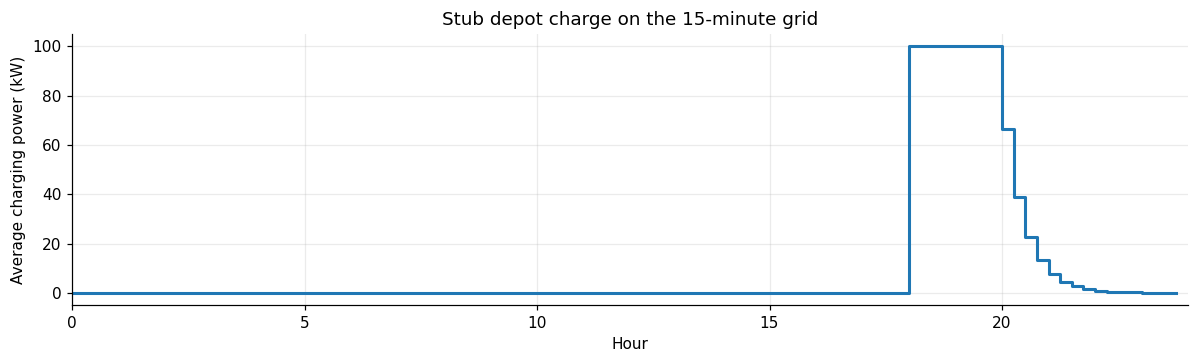

In [2]:
stub_schedule = DailySchedule(
    ev_id="bus_stage0_stub",
    day=0,
    day_type="representative_service_day",
    parking_events=[
        ParkingEvent(
            start_time=0.0,
            end_time=18.0,
            duration_hours=18.0,
            location_purpose="depot_terminus",
            can_charge=False,
            charge_power_kw=0.0,
        ),
        ParkingEvent(
            start_time=18.0,
            end_time=24.0,
            duration_hours=6.0,
            location_purpose="depot_terminus",
            can_charge=True,
            charge_power_kw=100.0,
        ),
    ],
)
stub_soc, stub_load_kw, stub_soc_end = simulate_single_day(
    stub_schedule,
    battery_capacity_kwh=300.0,
    soc_start=0.20,
)
unit_check = pd.DataFrame(
    [
        ("SOC steps", len(stub_soc)),
        ("load steps", len(stub_load_kw)),
        ("STEP_HOURS", STEP_HOURS),
        ("load_kw x STEP_HOURS", float(stub_load_kw.sum() * STEP_HOURS)),
        ("session energy_kwh", sum(event.energy_charged_kwh for event in stub_schedule.parking_events)),
        ("soc_end", stub_soc_end),
    ],
    columns=["metric", "value"],
)
display(unit_check)

hours = np.arange(STEPS_PER_DAY) * STEP_HOURS
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.step(hours, stub_load_kw, where="post", color="tab:blue", lw=2)
ax.set(xlabel="Hour", ylabel="Average charging power (kW)", title="Stub depot charge on the 15-minute grid")
ax.set_xlim(0, 24)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## A. What `all_blocks.parquet` is

,value
n_blocks,2.631200e+05
n_trips,1.668452e+06
pct_native,3.373784e+01
pct_inferred,6.626216e+01
pct_shape_distance,4.662885e+01
pct_stop_haversine_distance,5.337115e+01
stop_continuity_native,7.330800e+01
stop_continuity_inferred,4.954901e+01
pct_cross_midnight_blocks,9.450821e+00
layover_h_p50,9.999943e-02


,metric,value
0,max_distance_km,5.000000
1,n_unmatched_rows,9604.000000
2,pct_rows_unmatched,0.575623
3,start_distance_km_median,0.234215
4,start_distance_km_p99,1.851224
5,end_distance_km_median,0.234335
6,end_distance_km_p99,1.851224


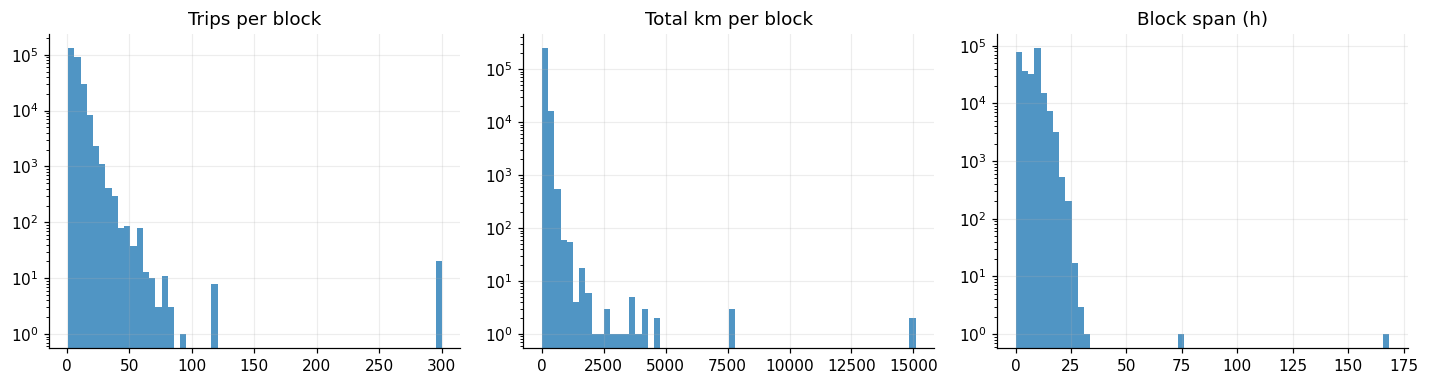

In [3]:
all_blocks = attach_lsoa(load_all_blocks(BLOCKS_PATH))
quality = summarize_block_quality(all_blocks)
display(quality.T.rename(columns={0: "value"}))

lsoa_join = all_blocks.attrs["lsoa_join"]
matched_start = all_blocks["start_lsoa"].ne("")
matched_end = all_blocks["end_lsoa"].ne("")
lsoa_qc = pd.DataFrame(
    [
        ("max_distance_km", lsoa_join["max_distance_km"]),
        ("n_unmatched_rows", lsoa_join["n_unmatched"]),
        ("pct_rows_unmatched", 100.0 * lsoa_join["n_unmatched"] / max(len(all_blocks), 1)),
        ("start_distance_km_median", all_blocks.loc[matched_start, "start_lsoa_distance_km"].median()),
        ("start_distance_km_p99", all_blocks.loc[matched_start, "start_lsoa_distance_km"].quantile(0.99)),
        ("end_distance_km_median", all_blocks.loc[matched_end, "end_lsoa_distance_km"].median()),
        ("end_distance_km_p99", all_blocks.loc[matched_end, "end_lsoa_distance_km"].quantile(0.99)),
    ],
    columns=["metric", "value"],
)
display(lsoa_qc)

block_stats = all_blocks.groupby("block_id").agg(
    n_trips=("trip_id", "count"),
    total_km=("distance_km", "sum"),
    start_h=("start_h", "min"),
    end_h=("end_h", "max"),
    block_source=("block_source", "first"),
)
block_stats["span_h"] = block_stats["end_h"] - block_stats["start_h"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title in zip(
    axes,
    ["n_trips", "total_km", "span_h"],
    ["Trips per block", "Total km per block", "Block span (h)"],
):
    ax.hist(block_stats[col], bins=60, color="tab:blue", alpha=0.78)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.grid(alpha=0.22)
plt.tight_layout()
plt.show()

## A.1. Trip endpoint LSOAs

The block table now carries nearest LSOA-21 labels on trip start and end points. The join is event-level: trips get origin and destination LSOAs, layovers inherit the previous trip's destination LSOA, and first/last depot dwell uses the surrounding trip endpoint.

## A.5. Honest labels for the data

In [4]:
q = quality.iloc[0]
honest_labels = pd.DataFrame(
    [
        ("Cross-midnight blocks", f"{q['pct_cross_midnight_blocks']:.1f}% of blocks have end_h >= 24", "Handled by splitting into day 0 and day 1 schedules."),
        ("Native vs inferred continuity", f"native {q['stop_continuity_native']:.1f}% / inferred {q['stop_continuity_inferred']:.1f}%", "Selection defaults to native; inferred quality is still reported."),
        ("Distance provenance", f"shape {q['pct_shape_distance']:.1f}% / stop_haversine {q['pct_stop_haversine_distance']:.1f}%", "Stop-haversine distance is a transparent fallback and likely underestimates by 15-25%."),
        ("Endpoint LSOAs", "nearest LSOA-21 centroid join, 5 km threshold", "Scotland / NI / offshore stops can stay empty; distance_km columns expose the QC."),
        ("Depot abstraction", "depot_terminus", "It marks first/last terminus dwell, not a real depot model."),
        ("Layover LSOA convention", "previous trip end_lsoa", "The location marks where the bus is parked, not where it heads next."),
        ("Vehicle subtype filter", "include={bus, minibus, unknown}", "Coach GenModels and obvious misclassifications are filtered at load time using Data/EV/manual/genmodel_subtype_lookup.csv."),
        ("Calendar missing", "service_id only", "The label is a representative service day, never a real date."),
    ],
    columns=["issue", "observed label", "notebook treatment"],
)
display(honest_labels)

,issue,observed label,notebook treatment
0,Cross-midnight blocks,9.5% of blocks have end_h >= 24,Handled by splitting into day 0 and day 1 sche...
1,Native vs inferred continuity,native 73.3% / inferred 49.5%,Selection defaults to native; inferred quality...
2,Distance provenance,shape 46.6% / stop_haversine 53.4%,Stop-haversine distance is a transparent fallb...
3,Endpoint LSOAs,"nearest LSOA-21 centroid join, 5 km threshold",Scotland / NI / offshore stops can stay empty;...
4,Depot abstraction,depot_terminus,"It marks first/last terminus dwell, not a real..."
5,Layover LSOA convention,previous trip end_lsoa,"The location marks where the bus is parked, no..."
6,Vehicle subtype filter,"include={bus, minibus, unknown}",Coach GenModels and obvious misclassifications...
7,Calendar missing,service_id only,"The label is a representative service day, nev..."


## B. Picking a protagonist

In [5]:
main_rng = np.random.default_rng(MAIN_BUS_SEED)
alt_rng = np.random.default_rng(ALT_BUS_SEED)
protagonist_id = sample_protagonist_block(all_blocks, main_rng)
contrast_id = sample_contrast_block(all_blocks, alt_rng, protagonist_id)

protagonist_card = render_block_identity_card(all_blocks, protagonist_id)
contrast_card = render_block_identity_card(all_blocks, contrast_id)
display(pd.concat([protagonist_card.assign(role="protagonist"), contrast_card.assign(role="contrast")], ignore_index=True))

vehicle_params = load_bus_vehicle_params(VEHICLE_PARAMS_PATH, fallback_depot_charge_kw=FALLBACK_DEPOT_CHARGE_KW)
vehicle_rng = np.random.default_rng(VEHICLE_SEED)
protagonist_vehicle = sample_bus_vehicle_specs(vehicle_params, vehicle_rng, n=1).iloc[0]
BUS_BATTERY_KWH = float(protagonist_vehicle["battery_kwh"])
BUS_CONSUMPTION_KWH_PER_KM = float(protagonist_vehicle["consumption_kwh_per_km"])
DEPOT_CHARGE_KW = float(protagonist_vehicle["depot_charge_kw"])

vehicle_summary = pd.DataFrame(
    [
        ("source rows", vehicle_params.attrs["input_rows"]),
        ("sampling rows", vehicle_params.attrs["sampling_rows"]),
        ("stock coverage", f"{vehicle_params.attrs['stock_coverage_pct']:.1f}%"),
        ("sampled make", protagonist_vehicle["make"]),
        ("sampled model", protagonist_vehicle["gen_model"]),
        ("subtype filter", ", ".join(vehicle_params.attrs.get("include_subtypes", ()))),
        ("dropped by subtype", str(vehicle_params.attrs.get("dropped_by_subtype", {}))),
        ("sampled subtype", str(protagonist_vehicle.get("subtype", ""))),
        ("battery_kwh", BUS_BATTERY_KWH),
        ("consumption_kwh_per_km", BUS_CONSUMPTION_KWH_PER_KM),
        ("depot_charge_kw", DEPOT_CHARGE_KW),
    ],
    columns=["metric", "value"],
)
display(vehicle_summary)

,block_id,agency_id,n_trips,total_km,span_h,service_id,distance_source_breakdown,stop_continuity,n_routes,service_day_label,role
0,96ecdc100da3a3a41b0b5d57e89d4ae12380c450,OP393,11,137.868103,5.466666,5847,shape=100.0%,0.500000,1,a representative service day,protagonist
1,d40493e37a9fb5372a7c2551f60906cd95573274,OP772,24,302.075409,17.066668,12508,shape=100.0%,0.478261,2,a representative service day,contrast


,metric,value
0,source rows,32
1,sampling rows,14
2,stock coverage,93.0%
3,sampled make,BYD
4,sampled model,BYD EBUS
5,subtype filter,"bus, minibus, unknown"
6,dropped by subtype,{'coach': 3}
7,sampled subtype,bus
8,battery_kwh,345.0
9,consumption_kwh_per_km,0.83


## C. Block -> schedule

,day,trip_id,route_id,departure_h,arrival_h,distance_km,energy_kwh,origin_lsoa,destination_lsoa
0,0,VJ42cff7261573bbd348dfc9b5c0fd153321691c49__d0,60001,9.416667,9.883333,12.430995,10.317726,E01021489,E01021520
1,0,VJ51e93d0ad8eb39c7408976f5177e0846293254e4__d0,60001,9.900000,10.366667,12.656425,10.504833,E01021520,E01021489
2,0,VJ4ceb4881d42d08f1ea785a16a7697dcdd1b2ccc9__d0,60001,10.416667,10.883333,12.430995,10.317726,E01021489,E01021520
3,0,VJ2bb89fcf8e4cf95feb04d899473565b8bb7f877f__d0,60001,10.900000,11.366667,12.656425,10.504833,E01021520,E01021489
4,0,VJd6a848fcf31f42ed271d31df1af4ce992caa687f__d0,60001,11.416667,11.883333,12.430995,10.317726,E01021489,E01021520
5,0,VJ3e1aaa999eb24ea872c6dfe78ee27f17fb214f32__d0,60001,11.900000,12.366667,12.656425,10.504833,E01021520,E01021489
6,0,VJa39a12b06e912fb61481a86f20a404d64859894f__d0,60001,12.416667,12.883333,12.430995,10.317726,E01021489,E01021520
7,0,VJba8d2bcc9a70b009f5b34f617f3c291e0117cc5d__d0,60001,12.900000,13.366667,12.656425,10.504833,E01021520,E01021489
8,0,VJ6a46ac5cb5ff5ec7a001e99b64c841fdcdc5714c__d0,60001,13.416667,13.883333,12.430995,10.317726,E01021489,E01021520
9,0,VJbb9544149024cc8dbb4b89f7d8517d65e2e1c67c__d0,60001,13.900000,14.366667,12.656425,10.504833,E01021520,E01021489


,day,purpose,start_h,end_h,duration_h,location_lsoa,can_charge,charge_power_kw
0,0,depot_terminus,0.000000,9.416667,9.416667,E01021489,True,100.0
1,0,layover,9.883333,9.900000,0.016666,E01021520,False,0.0
2,0,layover,10.366667,10.416667,0.050000,E01021489,False,0.0
3,0,layover,10.883333,10.900000,0.016666,E01021520,False,0.0
4,0,layover,11.366667,11.416667,0.050000,E01021489,False,0.0
5,0,layover,11.883333,11.900000,0.016666,E01021520,False,0.0
6,0,layover,12.366667,12.416667,0.050000,E01021489,False,0.0
7,0,layover,12.883333,12.900000,0.016666,E01021520,False,0.0
8,0,layover,13.366667,13.416667,0.050000,E01021489,False,0.0
9,0,layover,13.883333,13.900000,0.016666,E01021520,False,0.0


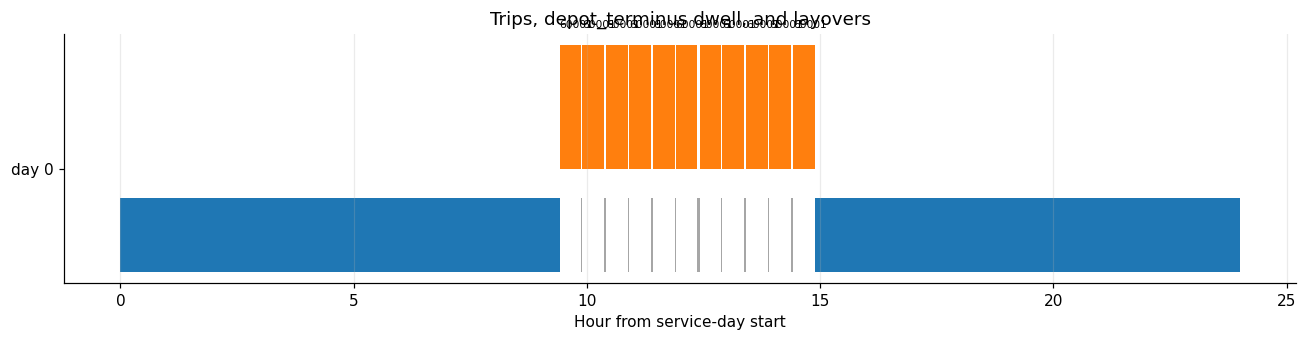

In [6]:
protagonist_block = all_blocks[all_blocks["block_id"].astype(str) == protagonist_id].copy()
schedules = block_to_daily_schedules(
    protagonist_block,
    ev_id=f"bus_{protagonist_id}",
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
)

trip_rows = []
parking_rows = []
for schedule in schedules:
    day_offset = schedule.day * 24.0
    for trip in schedule.trips:
        trip_rows.append(
            {
                "day": schedule.day,
                "trip_id": trip.trip_id,
                "route_id": getattr(trip, "route_id", ""),
                "departure_h": trip.departure_time,
                "arrival_h": trip.arrival_time,
                "distance_km": trip.distance_km,
                "energy_kwh": trip.energy_consumed_kwh,
                "origin_lsoa": trip.origin_lsoa,
                "destination_lsoa": trip.destination_lsoa,
            }
        )
    for event in schedule.parking_events:
        parking_rows.append(
            {
                "day": schedule.day,
                "purpose": event.location_purpose,
                "start_h": event.start_time,
                "end_h": event.end_time,
                "duration_h": event.duration_hours,
                "location_lsoa": event.location_lsoa,
                "can_charge": event.can_charge,
                "charge_power_kw": event.charge_power_kw,
            }
        )

trips_table = pd.DataFrame(trip_rows)
parking_table = pd.DataFrame(parking_rows)
display(trips_table.head(20))
display(parking_table.head(20))

fig, ax = plt.subplots(figsize=(12, max(3.2, len(schedules) * 1.8)))
colors = {"trip": "tab:orange", "depot_terminus": "tab:blue", "layover": "0.65"}
y = 0
for schedule in schedules:
    for event in schedule.parking_events:
        ax.broken_barh([(schedule.day * 24 + event.start_time, event.duration_hours)], (y - 0.35, 0.25), facecolors=colors[event.location_purpose])
    for trip in schedule.trips:
        ax.broken_barh([(schedule.day * 24 + trip.departure_time, trip.arrival_time - trip.departure_time)], (y, 0.42), facecolors=colors["trip"])
        ax.text(schedule.day * 24 + trip.departure_time, y + 0.48, str(getattr(trip, "route_id", "")), fontsize=7)
    y += 1
ax.set_yticks(range(len(schedules)))
ax.set_yticklabels([f"day {schedule.day}" for schedule in schedules])
ax.set_xlabel("Hour from service-day start")
ax.set_title("Trips, depot_terminus dwell, and layovers")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## D. Baseline SOC trajectory

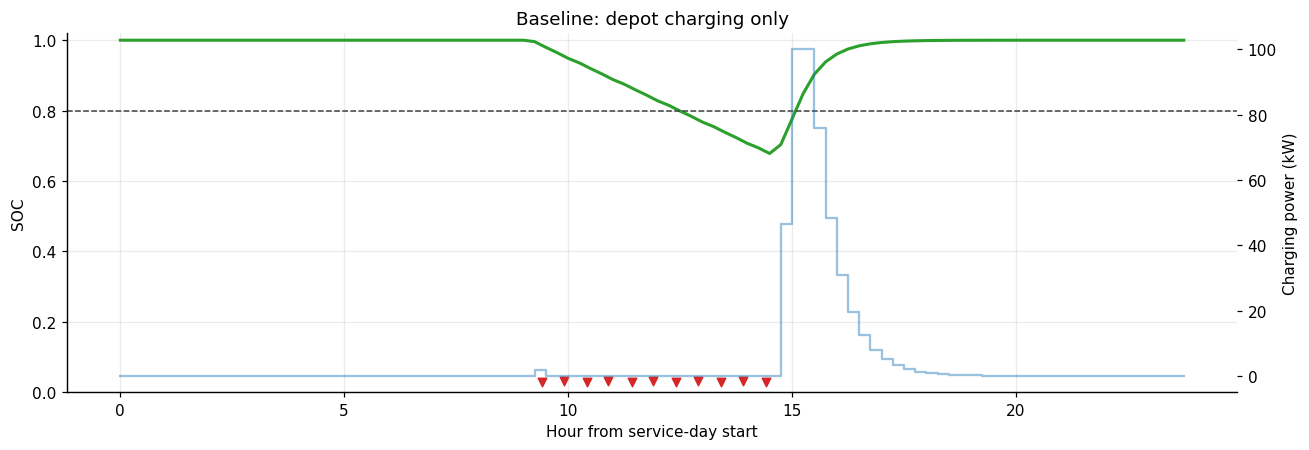

,soc_end,soc_min,energy_charged_kwh,depot_kwh,layover_kwh,total_consumed_kwh
0,1.0,0.678152,114.430509,114.430509,0.0,114.430521


In [7]:
baseline = simulate_block(
    protagonist_block,
    battery_kwh=BUS_BATTERY_KWH,
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
    allow_layover_charging=False,
)
time_h = np.arange(len(baseline["soc"])) * STEP_HOURS

fig, ax_soc = plt.subplots(figsize=(12, 4.2))
ax_load = ax_soc.twinx()
ax_soc.plot(time_h, baseline["soc"], color="tab:green", lw=2, label="SOC")
ax_load.step(time_h, baseline["load_kw"], where="post", color="tab:blue", alpha=0.45, label="load_kw")
for schedule in baseline["schedules"]:
    offset = schedule.day * 24.0
    for trip in schedule.trips:
        ax_soc.scatter(offset + trip.departure_time, max(0.0, trip.energy_consumed_kwh / BUS_BATTERY_KWH), marker="v", color="tab:red", s=30)
ax_soc.axhline(CV_THRESHOLD[DEFAULT_CHEMISTRY], color="0.25", ls="--", lw=1, label=f"CV threshold {DEFAULT_CHEMISTRY}")
ax_soc.set(xlabel="Hour from service-day start", ylabel="SOC", ylim=(0, 1.02))
ax_load.set_ylabel("Charging power (kW)")
ax_soc.set_title("Baseline: depot charging only")
ax_soc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(pd.DataFrame([{key: baseline[key] for key in ["soc_end", "soc_min", "energy_charged_kwh", "depot_kwh", "layover_kwh", "total_consumed_kwh"]}]))

## E. What if we charge during layovers

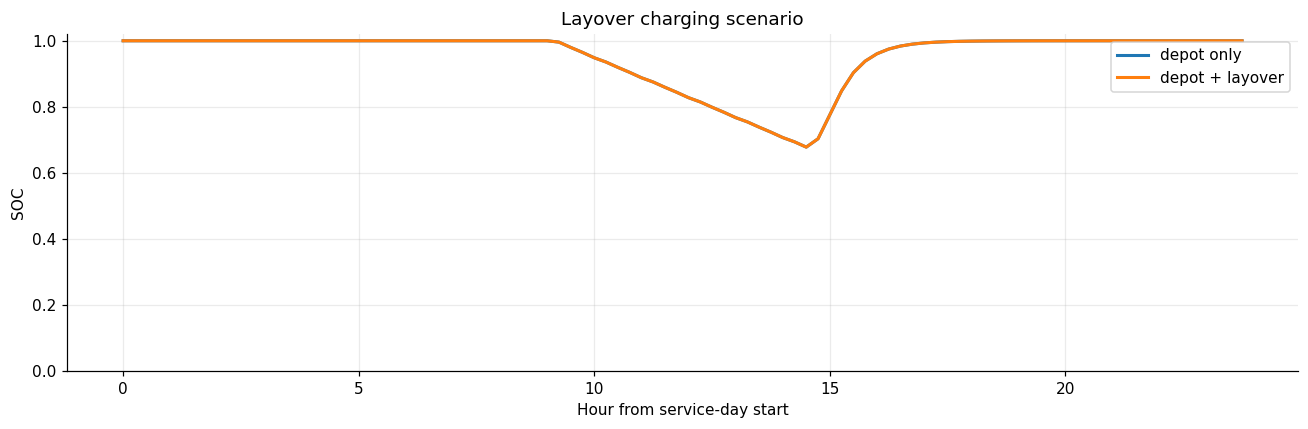

,scenario,soc_end,soc_min,energy_charged_kwh,depot_share
0,depot_only,1.0,0.678152,114.430509,1.0
1,depot_plus_layover,1.0,0.678152,114.430509,1.0


In [8]:
with_layover = simulate_block(
    protagonist_block,
    battery_kwh=BUS_BATTERY_KWH,
    consumption_kwh_per_km=BUS_CONSUMPTION_KWH_PER_KM,
    depot_charge_kw=DEPOT_CHARGE_KW,
    allow_layover_charging=True,
    layover_charge_kw=50.0,
    min_layover_for_charging_h=STEP_HOURS,
)

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(np.arange(len(baseline["soc"])) * STEP_HOURS, baseline["soc"], lw=2, label="depot only")
ax.plot(np.arange(len(with_layover["soc"])) * STEP_HOURS, with_layover["soc"], lw=2, label="depot + layover")
ax.set(xlabel="Hour from service-day start", ylabel="SOC", ylim=(0, 1.02), title="Layover charging scenario")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

compare = pd.DataFrame(
    [
        {
            "scenario": "depot_only",
            "soc_end": baseline["soc_end"],
            "soc_min": baseline["soc_min"],
            "energy_charged_kwh": baseline["energy_charged_kwh"],
            "depot_share": baseline["depot_kwh"] / max(baseline["energy_charged_kwh"], 1e-9),
        },
        {
            "scenario": "depot_plus_layover",
            "soc_end": with_layover["soc_end"],
            "soc_min": with_layover["soc_min"],
            "energy_charged_kwh": with_layover["energy_charged_kwh"],
            "depot_share": with_layover["depot_kwh"] / max(with_layover["energy_charged_kwh"], 1e-9),
        },
    ]
)
display(compare)

## F. Sensitivity grid

,battery_kwh,consumption_kwh_per_km,soc_end,soc_min,below_0_10
0,258.8,0.622,1.000000,0.678902,False
1,258.8,0.830,1.000000,0.571525,False
2,258.8,1.037,1.000000,0.464664,False
3,345.0,0.622,1.000000,0.758808,False
4,345.0,0.830,1.000000,0.678152,False
5,345.0,1.037,1.000000,0.597884,False
6,431.2,0.622,0.999999,0.806869,False
7,431.2,0.830,0.999999,0.742285,False
8,431.2,1.037,0.999998,0.678012,False


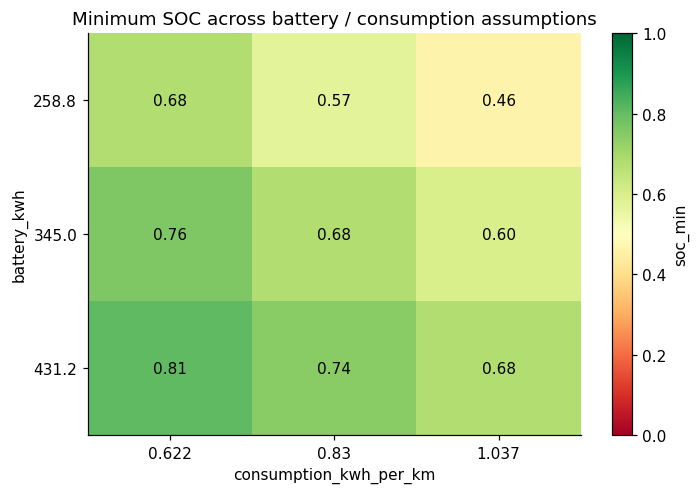

In [9]:
battery_grid = sorted({round(BUS_BATTERY_KWH * factor, 1) for factor in [0.75, 1.0, 1.25]})
consumption_grid = sorted({round(BUS_CONSUMPTION_KWH_PER_KM * factor, 3) for factor in [0.75, 1.0, 1.25]})
rows = []
for battery_kwh in battery_grid:
    for consumption_kwh_per_km in consumption_grid:
        result = simulate_block(
            protagonist_block,
            battery_kwh=battery_kwh,
            consumption_kwh_per_km=consumption_kwh_per_km,
            depot_charge_kw=DEPOT_CHARGE_KW,
            allow_layover_charging=False,
        )
        rows.append(
            {
                "battery_kwh": battery_kwh,
                "consumption_kwh_per_km": consumption_kwh_per_km,
                "soc_end": result["soc_end"],
                "soc_min": result["soc_min"],
                "below_0_10": result["soc_min"] < 0.10,
            }
        )
sensitivity = pd.DataFrame(rows)
display(sensitivity)

heat = sensitivity.pivot(index="battery_kwh", columns="consumption_kwh_per_km", values="soc_min")
fig, ax = plt.subplots(figsize=(6.6, 4.6))
im = ax.imshow(heat.values, vmin=0.0, vmax=1.0, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(heat.columns)), [str(col) for col in heat.columns])
ax.set_yticks(range(len(heat.index)), [str(idx) for idx in heat.index])
ax.set_xlabel("consumption_kwh_per_km")
ax.set_ylabel("battery_kwh")
ax.set_title("Minimum SOC across battery / consumption assumptions")
for i, battery_kwh in enumerate(heat.index):
    for j, consumption in enumerate(heat.columns):
        value = heat.loc[battery_kwh, consumption]
        marker = "!" if value < 0.10 else ""
        ax.text(j, i, f"{value:.2f}{marker}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="soc_min")
plt.tight_layout()
plt.show()

## H. Final identity card

In [10]:
dwell_by_purpose = parking_table.groupby("purpose")["duration_h"].sum()
final_card = pd.DataFrame(
    [
        {
            "block_id": protagonist_id,
            "agency_id": str(protagonist_block["agency_id"].iloc[0]),
            "n_trips_original": int(protagonist_block.shape[0]),
            "n_schedule_days": len(baseline["schedules"]),
            "total_km": round(baseline["total_km"], 2),
            "span_h": round(float(protagonist_block["end_h"].max() - protagonist_block["start_h"].min()), 2),
            "vehicle_make": protagonist_vehicle["make"],
            "vehicle_gen_model": protagonist_vehicle["gen_model"],
            "vehicle_stock_2025_q2": float(protagonist_vehicle["stock_2025_q2"]),
            "first_origin_lsoa": str(trips_table["origin_lsoa"].iloc[0]) if not trips_table.empty else "",
            "last_destination_lsoa": str(trips_table["destination_lsoa"].iloc[-1]) if not trips_table.empty else "",
            "depot_dwell_h": round(float(dwell_by_purpose.get("depot_terminus", 0.0)), 2),
            "layover_dwell_h": round(float(dwell_by_purpose.get("layover", 0.0)), 2),
            "total_consumed_kwh": round(baseline["total_consumed_kwh"], 2),
            "battery_kwh": BUS_BATTERY_KWH,
            "consumption_kwh_per_km": BUS_CONSUMPTION_KWH_PER_KM,
            "depot_charge_kw": DEPOT_CHARGE_KW,
            "soc_end_baseline": round(baseline["soc_end"], 4),
            "soc_min_baseline": round(baseline["soc_min"], 4),
            "soc_end_with_layover": round(with_layover["soc_end"], 4),
            "energy_charged_kwh_baseline": round(baseline["energy_charged_kwh"], 2),
        }
    ]
).T.rename(columns={0: "value"})
display(final_card)

print(f"Notebook runtime: {time.time() - NOTEBOOK_START:.1f}s")

,value
block_id,96ecdc100da3a3a41b0b5d57e89d4ae12380c450
agency_id,OP393
n_trips_original,11
n_schedule_days,1
total_km,137.87
span_h,5.47
vehicle_make,BYD
vehicle_gen_model,BYD EBUS
vehicle_stock_2025_q2,180.0
first_origin_lsoa,E01021489


Notebook runtime: 50.1s
